## 11. Timetable Collision Check

A timetable record is uniquely identified by `(fahrt_id, ort_nr_start, scheduled_arrival_time)`.

**Question**: do multiple stop events ever map to the same timetable record?

In [1]:
from pathlib import Path
import polars as pl

EVENTS = Path('../data/processed_with_signal_info/core_stop_events.parquet')

df = pl.read_parquet(EVENTS)
print(f'total events: {len(df):,}')
print(f'columns: {df.columns}')

total events: 973,393
columns: ['fzg_id', 'drop_row_idx', 'arrival_time', 'departure_time', 'linie', 'fahrt_id', 'ort_nr_start', 'stop_index', 'stop_status', 'scheduled_arrival_time', 'delay_calculated_sec', 'delay_recorded_sec', 'dwell_time', 'travel_time', 'besetztgrad', 'is_peak_hour', 'is_workday', 'has_traffic_signal']


## 1. Overall collision rate

In [2]:
TT_KEY = ['fahrt_id', 'ort_nr_start', 'scheduled_arrival_time']

# count how many events share the same timetable record
collision = (
    df
    .filter(pl.col('scheduled_arrival_time').is_not_null())
    .group_by(TT_KEY)
    .agg(pl.len().alias('n_events'))
)

n_tt_records  = len(collision)
n_collisions  = collision.filter(pl.col('n_events') > 1)
n_events_affected = (
    df
    .filter(pl.col('scheduled_arrival_time').is_not_null())
    .join(n_collisions.select(TT_KEY), on=TT_KEY, how='semi')
    .height
)

print(f'Unique timetable records matched:      {n_tt_records:>8,}')
print(f'Records with 2+ events (collisions):   {len(n_collisions):>8,}  ({len(n_collisions)/n_tt_records*100:.2f}%)')
print(f'Events involved in a collision:        {n_events_affected:>8,}  ({n_events_affected/len(df)*100:.2f}%)')
print()
print('n_events distribution for colliding records:')
print(n_collisions['n_events'].value_counts().sort('n_events'))

Unique timetable records matched:       951,686
Records with 2+ events (collisions):     21,688  (2.28%)
Events involved in a collision:          43,395  (4.46%)

n_events distribution for colliding records:
shape: (2, 2)
┌──────────┬───────┐
│ n_events ┆ count │
│ ---      ┆ ---   │
│ u32      ┆ u32   │
╞══════════╪═══════╡
│ 2        ┆ 21669 │
│ 3        ┆ 19    │
└──────────┴───────┘


## 2. Same vehicle vs. different vehicles

In [3]:
# For each colliding timetable record, check whether events come from same or different fzg_id
colliding_events = (
    df
    .filter(pl.col('scheduled_arrival_time').is_not_null())
    .join(n_collisions.select(TT_KEY), on=TT_KEY, how='inner')
)

per_record = (
    colliding_events
    .group_by(TT_KEY)
    .agg(
        pl.len().alias('n_events'),
        pl.col('fzg_id').n_unique().alias('n_vehicles'),
        pl.col('stop_status').unique().sort().str.join('/').alias('stop_statuses'),
        pl.col('arrival_time').min().alias('first_arrival'),
        pl.col('arrival_time').max().alias('last_arrival'),
    )
    .with_columns(
        pl.when(pl.col('n_vehicles') == 1)
          .then(pl.lit('same_vehicle'))
          .otherwise(pl.lit('diff_vehicle'))
          .alias('collision_type')
    )
)

print('Collision type breakdown:')
print(
    per_record
    .group_by('collision_type')
    .agg(pl.len().alias('n_records'))
    .sort('collision_type')
)
print()
print('stop_status combinations in collisions:')
print(
    per_record
    .group_by('stop_statuses')
    .agg(pl.len().alias('n_records'))
    .sort('n_records', descending=True)
)

Collision type breakdown:
shape: (2, 2)
┌────────────────┬───────────┐
│ collision_type ┆ n_records │
│ ---            ┆ ---       │
│ str            ┆ u32       │
╞════════════════╪═══════════╡
│ diff_vehicle   ┆ 11        │
│ same_vehicle   ┆ 21677     │
└────────────────┴───────────┘

stop_status combinations in collisions:
shape: (5, 2)
┌────────────────────┬───────────┐
│ stop_statuses      ┆ n_records │
│ ---                ┆ ---       │
│ str                ┆ u32       │
╞════════════════════╪═══════════╡
│ normal             ┆ 11703     │
│ no_door/normal     ┆ 9035      │
│ no_door            ┆ 937       │
│ multi_door/normal  ┆ 12        │
│ multi_door/no_door ┆ 1         │
└────────────────────┴───────────┘


## 3. Time gap between colliding events

Gap between first and last colliding event (seconds):
  p0  :      0.0 s
  p25 :     18.0 s
  p50 :     55.0 s
  p75 :     89.0 s
  p90 :    128.0 s
  p95 :    163.0 s
  p99 :    422.1 s
  p100:  32327.0 s


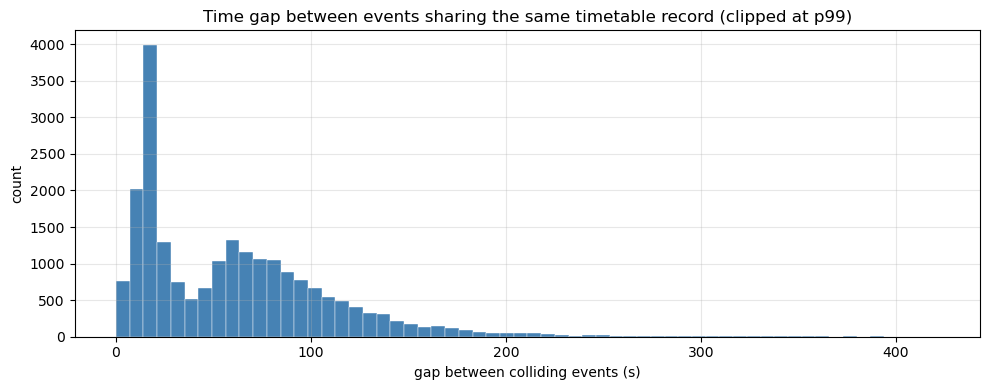

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# gap = last_arrival - first_arrival in seconds
gap_sec = (
    per_record
    .with_columns(
        ((pl.col('last_arrival') - pl.col('first_arrival')).dt.total_seconds())
        .alias('gap_sec')
    )
    ['gap_sec'].drop_nulls().to_numpy()
)

print('Gap between first and last colliding event (seconds):')
for p in [0, 25, 50, 75, 90, 95, 99, 100]:
    print(f'  p{p:<3d}: {np.percentile(gap_sec, p):>8.1f} s')

fig, ax = plt.subplots(figsize=(10, 4))
clip = np.percentile(gap_sec, 99)
ax.hist(gap_sec[gap_sec <= clip], bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_xlabel('gap between colliding events (s)')
ax.set_ylabel('count')
ax.set_title('Time gap between events sharing the same timetable record (clipped at p99)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('quality_report/11_collision_gap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Concrete examples

In [7]:
SHOW_COLS = ['fzg_id', 'drop_row_idx', 'arrival_time', 'fahrt_id',
             'ort_nr_start', 'stop_status', 'scheduled_arrival_time',
             'delay_calculated_sec']

for label, mask in [
    ('same_vehicle', per_record.filter(pl.col('collision_type') == 'same_vehicle')),
    ('diff_vehicle', per_record.filter(pl.col('collision_type') == 'diff_vehicle')),
]:
    if mask.is_empty():
        print(f'--- {label}: no cases ---\n')
        continue
    sample = mask.sample(min(3, len(mask)), seed=42)
    print(f'  {label.upper()}  ({len(mask):,} colliding records total)')
    for row in sample.iter_rows(named=True):
        key_filter = (
            (pl.col('fahrt_id') == row['fahrt_id']) &
            (pl.col('ort_nr_start') == row['ort_nr_start']) &
            (pl.col('scheduled_arrival_time') == row['scheduled_arrival_time'])
        )
        events = (
            df.filter(key_filter)
              .select(SHOW_COLS)
              .sort('arrival_time')
        )
        print(f"\n  fahrt_id={row['fahrt_id']}  ort_nr={row['ort_nr_start']}  "
              f"scheduled={row['scheduled_arrival_time']}")
        print(events.to_pandas().to_string(index=False))
    print()

  SAME_VEHICLE  (21,677 colliding records total)

  fahrt_id=23203203  ort_nr=687461  scheduled=2025-08-03 12:04:00+00:00
 fzg_id  drop_row_idx                     arrival_time  fahrt_id  ort_nr_start stop_status    scheduled_arrival_time  delay_calculated_sec
   2311         21524 2025-08-03 12:05:32.734104+00:00  23203203        687461      normal 2025-08-03 12:04:00+00:00             92.734104
   2311         21528 2025-08-03 12:06:03.746324+00:00  23203203        687461     no_door 2025-08-03 12:04:00+00:00            123.746324

  fahrt_id=27216228  ort_nr=654462  scheduled=2025-07-28 10:50:00+00:00
 fzg_id  drop_row_idx                     arrival_time  fahrt_id  ort_nr_start stop_status    scheduled_arrival_time  delay_calculated_sec
   1600          2747 2025-07-28 10:53:39.866782+00:00  27216228        654462      normal 2025-07-28 10:50:00+00:00            219.866782
   1600          2750 2025-07-28 10:53:57.859342+00:00  27216228        654462     no_door 2025-07-28 10:50:00